# JWST SN 1987A: calibrated infrared RGB

**Scientific question:** Can three calibrated NIRCam filters be compiled into a traceable RGB composite?

## Scientific audit protocol

This notebook is one part of a five-notebook case study of SN 1987A. It uses
either compact cutouts from named calibrated MAST FITS products, official NASA
release frames with their processing limits stated, or a peer-reviewed table
whose DOI and units are preserved. The object, coordinate, telescope,
instrument, filter, observing date, and original product name are kept in the
shared manifest. No image is presented as an unexplained illustration.

### Observation versus display

A calibrated FITS pixel and a public colour image are not interchangeable.
The JWST cutouts retain surface brightness in MJy/sr and an error extension.
They can support aperture sums and wavelength-dependent comparisons after
background subtraction. The Hubble release frames were already aligned,
combined, stretched, colour-mapped, compressed, and possibly resampled before
download. They can show where structures appear and can make a useful dated
animation, but their RGB values are not physical flux. The time-lapse notebook
therefore measures only within-frame morphology; calibrated brightness change
is analysed separately from published HST photometry.

An RGB composite is also a mapping, not what a human eye would see. Each
monochromatic infrared channel is assigned a visible colour and stretched to
reveal structure. The notebook records the assignment and shows every input
channel beside the composite. Scientific measurements use the unstretched
arrays, never the rendered RGB pixels. A colour difference is not called a
chemical detection: broad filters mix continuum and emission lines, and a
spectral or narrow-band analysis is needed to identify a constituent.

### Registration, resolution, and uncertainty

Images from different filters are placed on one celestial WCS grid before
pixel-level comparison. The code uses the output sky coordinates rather than
assuming equal array sizes or identical centring. When filters with different
point-spread functions are compared, the sharper images are blurred to a
common approximate resolution. The calculation is repeated across plausible
apertures or smoothing widths so one attractive processing choice cannot carry
the conclusion.

Background is measured away from the remnant. Random aperture uncertainty is
estimated from background scatter or from the published measurement error.
This does not include every calibration, PSF, aperture, or correlated-noise
term, so formal intervals are not promoted to publication-grade errors. For
the literature light curve, residual resampling is used because scatter about
the trend is more realistic than treating the very small tabulated statistical
errors as the only uncertainty.

### Claim boundary

“Validated” means the narrow archive measurement survived the checks named in
this notebook. “Reproduction” means a published table was independently
reanalysed and compared with the paper's conclusion. “Exploration” means the
product is useful for visual or method development but cannot support a
calibrated physical claim. None of these labels means a new supernova,
constituent, compact object, or explosion mechanism has been discovered.

The figures and small tables are saved beside the executed notebook. Each
`result.json` names the evidence figures, reusable artifacts, limitations,
quality checks, and provenance that feed the project dashboard. A null result,
unstable value, or mismatch is retained rather than edited away. This keeps the
repository useful as a learning record and makes the next required observation
or model explicit.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from scipy import ndimage, stats
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

RNG=np.random.default_rng(1999)
plt.style.use('seaborn-v0_8-whitegrid')
DATA=Path('../../data/sn1987a')
assert DATA.is_dir(), 'Run from the notebook folder inside a complete repository checkout.'
TARGET_RA=83.8666125; TARGET_DEC=-69.2697528

def load_fits(name):
    with fits.open(DATA/name,memmap=False) as h:
        sci=np.asarray(h['SCI'].data,float); err=np.asarray(h['ERR'].data,float) if 'ERR' in h else None
        return sci,err,WCS(h['SCI'].header).celestial,h['SCI'].header.copy()

def reproject_array(array,wcs_in,wcs_out,shape_out,order=1):
    yy,xx=np.indices(shape_out,dtype=float); sky=wcs_out.pixel_to_world(xx,yy); sx,sy=wcs_in.world_to_pixel(sky)
    return ndimage.map_coordinates(array,[sy,sx],order=order,mode='constant',cval=np.nan)

def pixel_scale_arcsec(wcs):
    return float(np.mean(proj_plane_pixel_scales(wcs))*3600)

def stretch(array,low=1,high=99.7,a=8):
    lo,hi=np.nanpercentile(array,[low,high]); z=np.clip((array-lo)/(hi-lo),0,1)
    return np.arcsinh(a*z)/np.arcsinh(a)

Set OBSGEO-B to   -16.371046 from OBSGEO-[XYZ].
Set OBSGEO-H to 1478832142.256 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -16.348296 from OBSGEO-[XYZ].
Set OBSGEO-H to 1478590370.632 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -16.348305 from OBSGEO-[XYZ].
Set OBSGEO-H to 1478590470.575 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


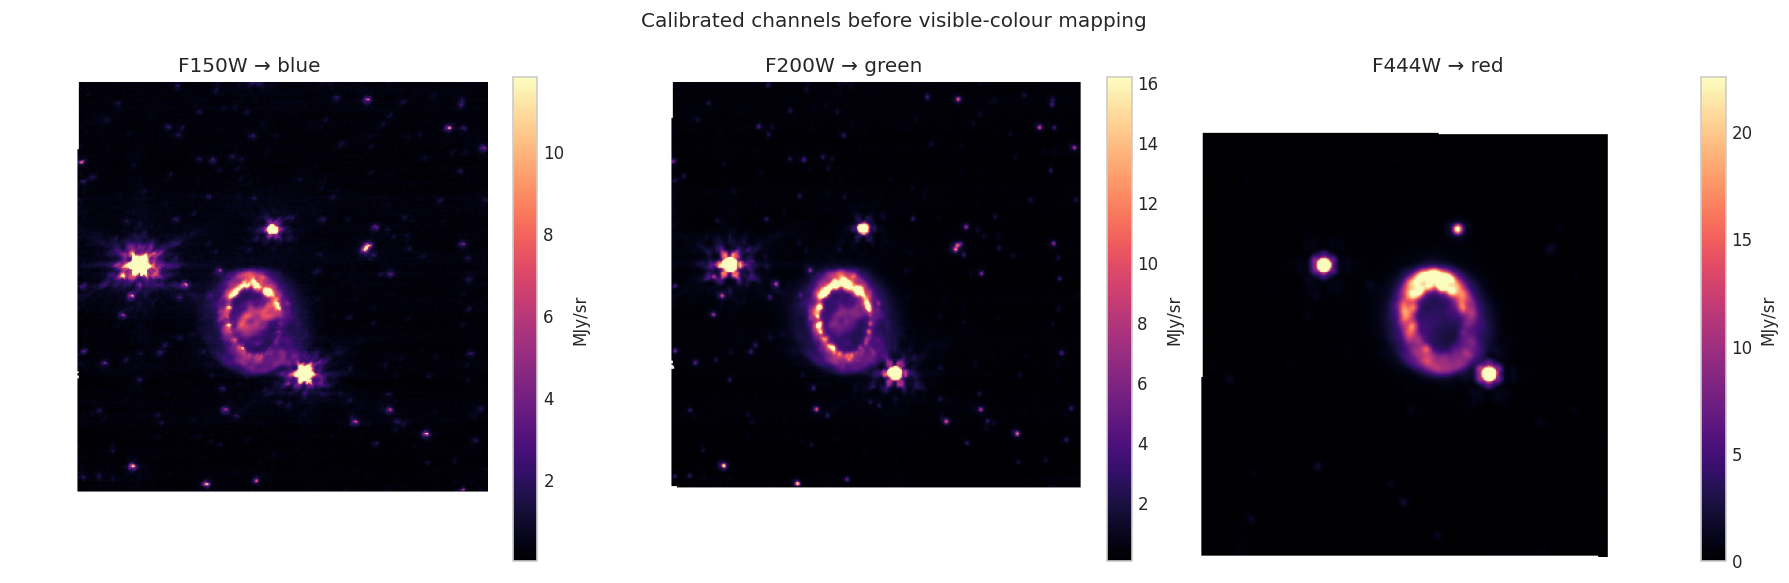

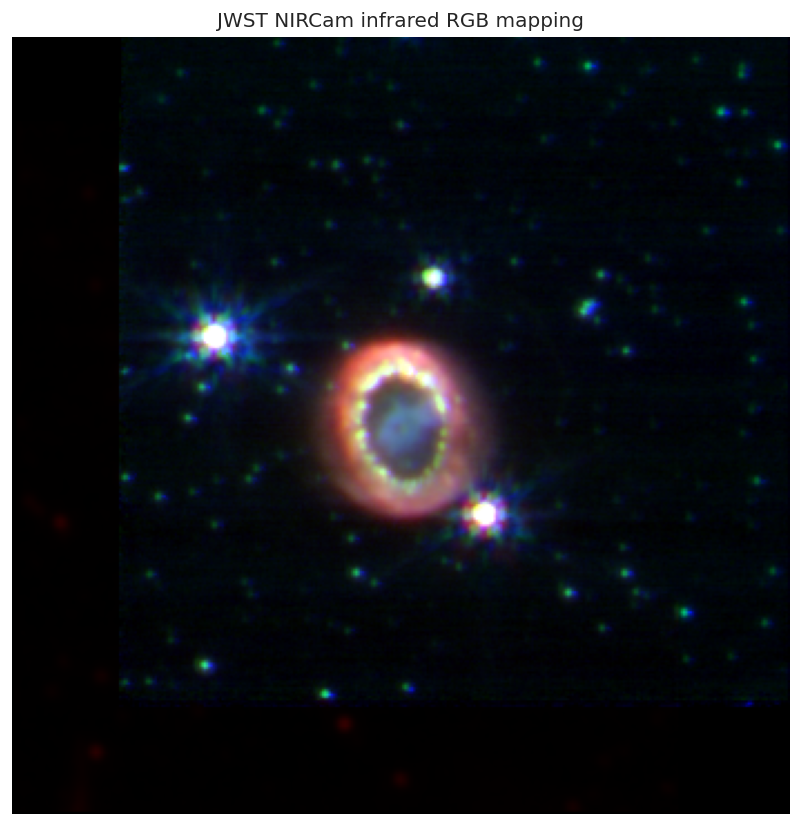

In [2]:
f150,e150,w150,h150=load_fits('jwst_f150w_2022_cutout.fits'); f200,e200,w200,h200=load_fits('jwst_f200w_2022_cutout.fits'); f444,e444,w444,h444=load_fits('jwst_f444w_2022_cutout.fits')
g200=reproject_array(f200,w200,w150,f150.shape); r444=reproject_array(f444,w444,w150,f150.shape); channels={'F150W → blue':f150,'F200W → green':g200,'F444W → red':r444}
stretched={name:stretch(value) for name,value in channels.items()}; rgb=np.dstack([stretched['F444W → red'],stretched['F200W → green'],stretched['F150W → blue']]); rgb=np.nan_to_num(rgb); plt.imsave('jwst_sn1987a_rgb.png',rgb)
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,(name,array) in zip(axes,channels.items()): im=ax.imshow(array,origin='lower',cmap='magma',vmin=np.nanpercentile(array,2),vmax=np.nanpercentile(array,99.5)); ax.set_title(name); ax.axis('off'); fig.colorbar(im,ax=ax,fraction=.046,label='MJy/sr')
fig.suptitle('Calibrated channels before visible-colour mapping'); fig.tight_layout(); fig.savefig('jwst_sn1987a_channel_panels.png',dpi=180); plt.show()
fig,ax=plt.subplots(figsize=(7,7)); ax.imshow(rgb,origin='lower'); ax.set_title('JWST NIRCam infrared RGB mapping'); ax.axis('off'); fig.tight_layout(); fig.savefig('jwst_sn1987a_rgb_figure.png',dpi=200); plt.show()
stats_table=pd.DataFrame([{'filter':name.split()[0],'unit':'MJy/sr','p01':np.nanpercentile(arr,1),'median':np.nanmedian(arr),'p997':np.nanpercentile(arr,99.7),'mapping':name.split('→')[-1].strip()} for name,arr in channels.items()]); stats_table.to_csv('jwst_rgb_channel_statistics.csv',index=False)

In [3]:
scale=pixel_scale_arcsec(w150); results=[f'F150W, F200W, and F444W calibrated cutouts mapped to blue, green, and red',f'common output grid {f150.shape[1]} × {f150.shape[0]} pixels at {scale:.4f} arcsec/pixel',f'each channel uses a recorded 1st–99.7th percentile asinh display stretch']
result={'id':'2026-08-01-jwst-sn1987a-rgb','title':'JWST SN 1987A: calibrated NIRCam RGB reconstruction','archive':'MAST · JWST NIRCam','date':'2026-08-01','question':'Can three calibrated NIRCam filters be registered and mapped into a traceable infrared RGB composite?','sample_size':int(np.isfinite(f150).sum()+np.isfinite(g200).sum()+np.isfinite(r444).sum()),'results':results,'validation':'Every channel is shown in calibrated units before stretching, all pixels are placed on the F150W celestial grid, and the mapping is stored in a CSV.','notebook':'mast/2026-08-01-jwst-sn1987a-rgb/notebook.ipynb','hero':'mast/2026-08-01-jwst-sn1987a-rgb/jwst_sn1987a_rgb_figure.png','figures':['mast/2026-08-01-jwst-sn1987a-rgb/jwst_sn1987a_rgb_figure.png','mast/2026-08-01-jwst-sn1987a-rgb/jwst_sn1987a_channel_panels.png'],'research_level':'Validated','claim_type':'Calibrated image reconstruction','provenance':['MAST JWST program 1726, PI Matsuura','jw01726-o001_t001 NIRCam I2D mosaics','F150W, F200W, F444W observed 2022-09-02'],'artifacts':['data/sn1987a/jwst_f150w_2022_cutout.fits','data/sn1987a/jwst_f200w_2022_cutout.fits','data/sn1987a/jwst_f444w_2022_cutout.fits','mast/2026-08-01-jwst-sn1987a-rgb/jwst_sn1987a_rgb.png','mast/2026-08-01-jwst-sn1987a-rgb/jwst_rgb_channel_statistics.csv'],'quality_checks':[{'name':'Calibrated I2D inputs','status':'pass'},{'name':'WCS reprojection','status':'pass'},{'name':'Input channels exposed','status':'pass'},{'name':'True-colour claim','status':'not made'}],'limitations':['visible colours are assigned to infrared bands','independent display stretches suppress absolute colour ratios','broad filters do not uniquely identify chemical species'],'tags':['JWST','SN 1987A','RGB','NIRCam']}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n'); print(stats_table.to_string(index=False))
assert rgb.shape[-1]==3 and np.isfinite(rgb).all()

F150W, F200W, and F444W calibrated cutouts mapped to blue, green, and red
common output grid 349 × 349 pixels at 0.0309 arcsec/pixel
each channel uses a recorded 1st–99.7th percentile asinh display stretch
filter   unit       p01   median      p997 mapping
 F150W MJy/sr -0.024742 0.308511 18.161467    blue
 F200W MJy/sr  0.005350 0.264783 25.443873   green
 F444W MJy/sr -0.043469 0.032122 26.566267     red


In [4]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                  name   status
 Calibrated I2D inputs     pass
      WCS reprojection     pass
Input channels exposed     pass
     True-colour claim not made


In [5]:
assert Path(Path(result['hero']).name).is_file()

In [6]:
assert all(Path(Path(path).name).is_file() for path in result['figures'])

## Interpretation and references

The composite is reproducible false colour. Blue is the shortest wavelength
and red the longest, following a chromatic ordering, but it is not a human-eye
view. The official six-filter release uses additional narrow bands and a more
complex colour assignment. Scientific statements about H₂, dust, synchrotron
continuum, or individual ions require the narrow-band and spectroscopic
analysis in the cited literature.

- Matsuura et al. (2024), deep JWST/NIRCam imaging: https://doi.org/10.1093/mnras/stae1381
- NASA official filter mapping: https://science.nasa.gov/asset/webb/supernova-1987a-nircam-image/
- MAST JWST primer: https://outerspace.stsci.edu/spaces/MASTDOCS/pages/153686810/MAST+Primer+for+JWST